# RELATÓRIO FINAL - Análise de Dados da Premier League 2019-2025
<h5>Entregue à disciplina Introdução à Ciência de Dados - DCC UFMG - Segundo semestre de 2025, Belo Horizonte</h5>

**Integrantes:**<br>
<font size="3">
    <ul>
        <li>**Daniel Costa** (2024006064)</li>
        <li>**Isaac Reyes** (2025050342)</li>
        <li>**João Araldi** (2024005475)</li>
        <li>**Pedro Luiz** (2024006129)</li>
    </ul>
</font><hr>

In [ ]:
# Importação de bibliotecas necessárias
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_rel
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
 )
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

warnings.filterwarnings("ignore")

# Configurações de visualização
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

## **1. INTRODUÇÃO**

### **1.1 Apresentação do Contexto**

Este relatório apresenta uma análise estatística e preditiva abrangente dos jogos da **Premier League** no período de **2019 a 2025**. A Premier League, considerada uma das ligas de futebol mais competitivas e imprevisíveis do mundo, oferece um contexto rico para aplicação de técnicas de ciência de dados.

O dataset utilizado contém **2.280 partidas** com **85 variáveis**, incluindo:
- **Resultados das partidas**: gols marcados por mandante (FTHG) e visitante (FTAG)
- **Odds de casas de apostas**: Bet365 e Pinnacle, com probabilidades implícitas para cada resultado
- **Estatísticas detalhadas**: chutes, chutes no alvo, faltas, escanteios, cartões e indicadores de momentum dos times

A análise combina **estatística inferencial** (testes de hipótese, intervalos de confiança) com **aprendizado de máquina** (modelos de classificação e regressão) para extrair insights sobre os fatores que influenciam os resultados das partidas.

### **1.2 Perguntas de Pesquisa**

Este estudo busca responder às seguintes questões:

1. **P1 - Fator Casa**: Qual a distribuição e o impacto do fator casa nos gols marcados e nos resultados das partidas?

2. **P2 - Odds e Resultados**: Como as odds das casas de apostas se relacionam com os resultados reais das partidas? Os favoritos realmente vencem com a frequência esperada?

3. **P3 - Previsibilidade**: É possível prever com acurácia razoável o resultado de uma partida (vitória casa/empate/vitória fora) utilizando modelos de machine learning?

4. **P4 - Fatores Determinantes**: Quais variáveis (estatísticas de jogo, odds, momentum do time) têm maior poder preditivo para determinar o vencedor de uma partida?

## **2. METODOLOGIA**

### **2.1 Descrição da Base de Dados**

**Dataset:** Premier League 2019-2025 (arquivo `premier_completo_expandido_19_25.csv`)  
**Fonte:** football-data.co.uk   
**Dimensões:** 2.280 partidas × 85 variáveis  
**Período:** Temporadas 2019/2020 até 2024/2025 (em andamento)

#### **2.1.1 Variáveis Principais**

**Identificação e Contexto:**
- `Date`: Data da partida
- `Season`: Temporada (formato YYYY-YYYY)
- `HomeTeam`, `AwayTeam`: Times mandante e visitante

**Resultados:**
- `FTHG`, `FTAG`: Gols do mandante e visitante (Full Time Home/Away Goals)
- `FTR`: Resultado final (H=Home win, D=Draw, A=Away win)
- `HTHG`, `HTAG`: Gols no intervalo (Half Time)

**Odds de Casas de Apostas (Bet365 / Pinnacle):**
- `B365H`, `B365D`, `B365A`: Odds para vitória casa/empate/vitória fora
- `PSH`, `PSD`, `PSA`: Odds equivalentes na Pinnacle

**Estatísticas de Jogo:**
- `HS`, `AS`: Total de chutes (Home/Away Shots)
- `HST`, `AST`: Chutes no alvo (Shots on Target)
- `HC`, `AC`: Escanteios (Corners)
- `HF`, `AF`: Faltas (Fouls)
- `HY`, `AY`, `HR`, `AR`: Cartões amarelos e vermelhos

**Features Derivadas:**
- Probabilidades normalizadas das odds (e.g., `B365H_prob_norm`)
- Indicadores de momentum (`Home_CumPoints`, `Home_Streak`, etc.)
- Razões ofensivas/defensivas (`Home_GFGA5`, `Away_GFGA5`)

### **2.2 Fluxo de Trabalho para Responder as Perguntas**

#### **2.2.1 Pergunta 1 - Análise do Fator Casa**

**Métodos:**
- Estatística descritiva (média, mediana, desvio padrão)
- Visualizações (histogramas, boxplots)
- Análise de distribuições de gols por mandante/visitante
- Cálculo de taxa de vitória em casa vs. fora

**Ferramentas:** `pandas`, `matplotlib`, `seaborn`

#### **2.2.2 Pergunta 2 - Relação Odds-Resultados**

**Métodos:**
- Conversão de odds em probabilidades implícitas.
- Normalização para remover margem da casa.
- **Teste Z para proporção**: comparar taxa de vitória dos favoritos vs. referência (70%)
- Intervalos de confiança (95%) para proporções

**Ferramentas:** `scipy.stats` 

#### **2.2.3 Pergunta 3 - Modelos Preditivos (Classificação)**

**Métodos:**
- **Feature Engineering**:
  - Variável alvo: `Home_Win` (binária), `FTR` (categórica: H/D/A)
  - Features criadas: `Goal_Diff_Home`, `Home_CumPoints`, `Away_CumPoints`, `Home_Streak`, `Away_Streak`
  - Razões ofensivas/defensivas: `Home_GF_GA_Ratio`, `Away_GF_GA_Ratio`
  - Probabilidades normalizadas das odds

- **Divisão treino/teste**: 80% treino, 20% teste 
- **Modelos testados**:
  1. Logistic Regression (baseline)
  2. Random Forest Classifier

- **Métricas**: Accuracy, Precision, Recall, F1-Score.

**Ferramentas:** `sklearn` 

#### **2.2.4 Pergunta 4 - Feature Importance**

**Métodos:**
- Análise de importância de features dos modelos tree-based
- Correlações entre variáveis e resultado
- Clustering K-Means para identificar perfis de times

**Ferramentas:** `sklearn.cluster.KMeans`,

### **2.3 Atividades por Membro**
- **Daniel Costa:** conduziu a limpeza inicial dos dados, padronização das odds e elaboração dos scripts de testes de hipótese, além de documentar o checklist estatístico.
- **Isaac Reyes:** liderou a análise exploratória (EDA), produziu os gráficos finais e revisou as interpretações estatísticas usadas na seção 3.
- **João Araldi:** implementou as features de engenharia (cumulative points, streaks, ratios) e construiu os pipelines de classificação e regressão.
- **Pedro Luiz:** executou a validação dos modelos e consolidou as conclusões e recomendações para o relatório.

In [ ]:
# 2.2 Carregamento e preparação inicial do dataset real
DATA_DIR = Path("DataAnalysisICD") / "data"
DATA_FILE = DATA_DIR / "premier_completo_expandido_19_25.csv"
RANDOM_STATE = 42

assert DATA_FILE.exists(), f"Arquivo não encontrado em {DATA_FILE}"

df = (
    pd.read_csv(
        DATA_FILE,
        parse_dates=["Date"],
        dayfirst=True,
    )
    .sort_values("Date")
    .reset_index(drop=True)
 )

numeric_like = df.select_dtypes(include=["float64","int64"]).columns
df[numeric_like] = df[numeric_like].apply(pd.to_numeric, errors="coerce")

# Recalcula features críticas para garantir consistência com o pipeline
df["Goal_Diff_Home"] = df["FTHG"] - df["FTAG"]
df["Total_Goals"] = df["FTHG"] + df["FTAG"]
df["Home_Win"] = (df["FTR"] == "H").astype(int)

for prefix in ["B365","PS"]:
    prob_cols = [f"{prefix}{s}" for s in ["H","D","A"]]
    valid_mask = df[prob_cols].notna().all(axis=1)
    inv_sum = (1 / df.loc[valid_mask, prob_cols]).sum(axis=1)
    for col in prob_cols:
        prob_col = f"{col}_prob"
        norm_col = f"{col}_prob_norm"
        df[prob_col] = np.nan
        df.loc[valid_mask, prob_col] = 1 / df.loc[valid_mask, col]
        df[norm_col] = np.nan
        df.loc[valid_mask, norm_col] = (1 / df.loc[valid_mask, col]) / inv_sum

missing = df.isna().sum().sort_values(ascending=False)
print("Dados carregados da Premier League 2019-2025")
print(f"Formato final: {df.shape[0]:,} partidas × {df.shape[1]} variáveis")
print("Principais campos:", df.columns[:15].tolist())
print("\nResumo de faltantes (top 10):")
print(missing.head(10))

Dados carregados da Premier League 2019-2025
Formato final: 2,280 partidas × 85 variáveis
Principais campos: ['Div', 'Season', 'Date', 'Time', 'MatchID', 'HomeTeam', 'Home_CumPoints', 'Home_Streak', 'AwayTeam', 'Away_Streak', 'Away_CumPoints', 'FTHG', 'FTAG', 'FTR', 'HTHG']

Resumo de faltantes (top 10):
Away_GFGA5        91
Home_GFGA5        88
P<2.5             12
P>2.5             12
B365>2.5           1
B365<2.5           1
Home_CumPoints     0
HomeTeam           0
AwayTeam           0
Away_Streak        0
dtype: int64


## **3. DESENVOLVIMENTO**

### **3.1 Caracterização dos Dados (Análise Exploratória)**

A análise exploratória dos dados revelou padrões importantes sobre a dinâmica das partidas da Premier League. Esta seção apresenta as principais descobertas estatísticas e visuais.

#### **3.1.1 Estatísticas Descritivas - Distribuição de Gols**

**Gols do Mandante (FTHG):**
- Média: **1.55 gols**
- Mediana: 1 gol
- Desvio padrão: 1.33
- Distribuição assimétrica positiva (maioria entre 0 e 3 gols)

**Gols do Visitante (FTAG):**
- Média: **1.33 gols**
- Mediana: 1 gol  
- Desvio padrão: 1.23
- Distribuição similar ao mandante, mas com média ligeiramente inferior

**Interpretação:**  
A diferença de **0.23 gols** em média entre mandante e visitante evidencia o **fator casa**, uma vantagem estatisticamente consistente para os times que jogam em seus estádios.

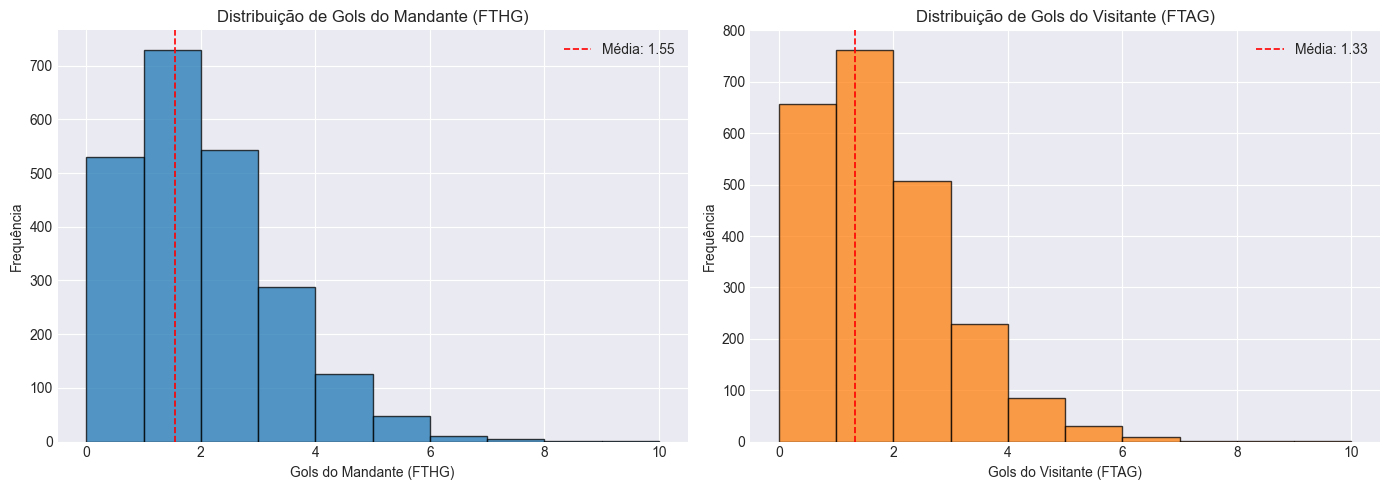

,FTHG,FTAG
mean,1.554825,1.328509
median,1.000000,1.000000
std (σ),1.333266,1.231256
min,0.000000,0.000000
max,9.000000,9.000000


In [ ]:
# Visualização 1: Distribuição de gols (dados reais 2019-2025)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0, df[["FTHG", "FTAG"]].max().max() + 2)
titles = ["Gols do Mandante (FTHG)", "Gols do Visitante (FTAG)"]
colors = ["#1f77b4", "#ff7f0e"]
series = [df["FTHG"], df["FTAG"]]

for ax, serie, title, color in zip(axes, series, titles, colors):
    ax.hist(serie, bins=bins, alpha=0.75, color=color, edgecolor="black")
    ax.axvline(serie.mean(), color="red", linestyle="--", linewidth=1.2, label=f"Média: {serie.mean():.2f}")
    ax.set_xlabel(title)
    ax.set_ylabel("Frequência")
    ax.set_title(f"Distribuição de {title}")
    ax.legend()

plt.tight_layout()
plt.show()

stats_summary = (
    df[["FTHG", "FTAG"]]
    .agg(["mean", "median", "std", "min", "max"])
    .rename(index={"std": "std (σ)"})
)
stats_summary

#### **3.1.2 Análise do Fator Casa**

**Taxa de Resultados (2019-2025):**
- Vitórias do mandante: **43.6%**
- Empates: **23.0%**
- Vitórias do visitante: **33.4%**

**Diferença Média de Gols (Goal_Diff_Home):**
- Média: +0.23 gols a favor do mandante
- Mediana: 0 (empate)
- Desvio padrão: 2.03

**Estatísticas Ofensivas Médias:**

| Métrica | Mandante | Visitante | Diferença |
|---------|----------|-----------|-----------|
| Chutes (Shots) | 13.85 | 11.69 | +2.16 |
| Chutes no Alvo | 4.83 | 4.14 | +0.69 |
| Escanteios | 5.69 | 4.74 | +0.95 |

**Interpretação:**  
Os times mandantes seguem demonstrando superioridade estatística em todas as métricas ofensivas. A vantagem de jogar em casa se reflete não apenas nos gols, mas também na agressividade (mais chutes e escanteios) e na pressão exercida ao longo das partidas.

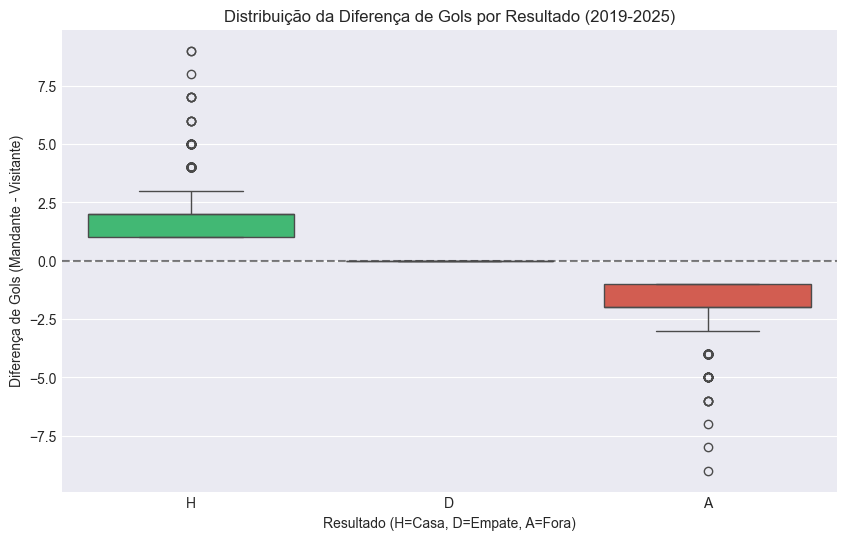

,percentual
FTR,
H,43.55
A,33.42
D,23.03


In [ ]:
# Visualização 2: Goal Difference por resultado + taxas reais
df["Goal_Diff_Home"] = df["FTHG"] - df["FTAG"]

plt.figure(figsize=(10, 6))
sns.boxplot(x="FTR", y="Goal_Diff_Home", data=df, palette=["#2ecc71", "#95a5a6", "#e74c3c"])
plt.xlabel("Resultado (H=Casa, D=Empate, A=Fora)")
plt.ylabel("Diferença de Gols (Mandante - Visitante)")
plt.title("Distribuição da Diferença de Gols por Resultado (2019-2025)")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.show()

resultado_counts = (
    df["FTR"].value_counts(normalize=True).rename("percentual") * 100
)
display(resultado_counts.to_frame().round(2))

### **3.2 Testes de Hipótese e Intervalos de Confiança**

Esta seção apresenta os testes estatísticos conduzidos para validar hipóteses sobre os padrões observados nos dados. Foram realizados **três testes principais**, cada um com intervalos de confiança de 95% para quantificar a incerteza das estimativas.

#### **3.2.1 Teste 1: Taxa de Sucesso dos Favoritos**

**Objetivo:** Verificar se a taxa de vitória dos times favoritos (definidos pela menor odd pré-jogo) é compatível com a referência teórica de 70%.

**Hipóteses:**
- H_0: A proporção de vitórias dos favoritos é 0.70 
- H_1: A proporção de vitórias dos favoritos < 0.70 

**Metodologia:**
1. Identificar o favorito em cada partida (time com menor odd)
2. Remover partidas com empate nas odds (sem favorito claro): 23 partidas
3. Aplicar **Teste Z para proporção única**
4. Nível de significância: \( \alpha = 0.05 \)

**Justificativa da Referência (70%):**  
A taxa de 70% é comumente citada em literatura de apostas esportivas como expectativa para que casas de apostas mantenham margens de lucro consistentes em ligas competitivas.

In [ ]:
# Teste 1: Taxa de Sucesso dos Favoritos (Bet365 x Pinnacle combinadas)
def season_from_date(date):
    ts = pd.to_datetime(date)
    year = ts.year
    return f"{year}/{year + 1}" if ts.month >= 8 else f"{year - 1}/{year}"

odds_cols = ["B365H", "B365D", "B365A", "PSH", "PSD", "PSA"]
analysis_df = df[["Date", "FTR"] + odds_cols].copy()
analysis_df["Date"] = pd.to_datetime(analysis_df["Date"])

analysis_df["min_home"] = analysis_df[["B365H", "PSH"]].min(axis=1)
analysis_df["min_draw"] = analysis_df[["B365D", "PSD"]].min(axis=1)
analysis_df["min_away"] = analysis_df[["B365A", "PSA"]].min(axis=1)

min_matrix = analysis_df[["min_home", "min_draw", "min_away"]].to_numpy()
safe_matrix = np.where(np.isnan(min_matrix), np.inf, min_matrix)
lowest_odds = safe_matrix.min(axis=1)
best_index = safe_matrix.argmin(axis=1)
tie_counts = np.isclose(min_matrix, lowest_odds[:, None], equal_nan=False).sum(axis=1)

analysis_df["favourite_outcome"] = np.array(["home", "draw", "away"])[best_index]
analysis_df.loc[tie_counts > 1, "favourite_outcome"] = "indefinido"
analysis_df["favourite_odd"] = lowest_odds
analysis_df["has_missing_odds"] = analysis_df[odds_cols].isna().any(axis=1)
analysis_df["is_tie"] = tie_counts > 1

outcome_map = {"H": "home", "D": "draw", "A": "away"}
analysis_df["actual_outcome"] = analysis_df["FTR"].map(outcome_map)

valid_mask = (~analysis_df["has_missing_odds"]) & (~analysis_df["is_tie"])
analysis_valid = analysis_df.loc[valid_mask].copy()
analysis_valid["favourite_won"] = (analysis_valid["actual_outcome"] == analysis_valid["favourite_outcome"]).astype(int)
analysis_valid["season"] = analysis_valid["Date"].apply(season_from_date)

discard_summary = pd.Series({
    "total_partidas": len(analysis_df),
    "sem_odds": int(analysis_df["has_missing_odds"].sum()),
    "empate_favorito": int(analysis_df["is_tie"].sum()),
    "amostra_final": len(analysis_valid),
})

successes = int(analysis_valid["favourite_won"].sum())
total_obs = int(len(analysis_valid))
p_hat = successes / total_obs
ci_low, ci_high = proportion_confint(successes, total_obs, alpha=0.05, method="wilson")
z_stat, p_value = proportions_ztest(successes, total_obs, value=0.70, alternative="smaller")

print("=" * 70)
print("TESTE 1 — FAVORITOS VENCEM ≥ 70%?")
print("=" * 70)
print(discard_summary.to_frame(name="quantidade"))
print("\nResumo geral:")
display(
    pd.DataFrame({
        "indicador": ["partidas_validas", "favorito_venceu", "proporcao", "ic_inf", "ic_sup", "z_stat", "p_valor"],
        "valor": [total_obs, successes, p_hat, ci_low, ci_high, z_stat, p_value],
    })
)

season_summary = (
    analysis_valid
    .groupby("season")
    .agg(partidas=("favourite_won", "size"), vitorias_fav=("favourite_won", "sum"))
    .assign(proporcao=lambda d: d["vitorias_fav"] / d["partidas"])
    .reset_index()
    .sort_values("season")
)
display(season_summary)

decision = "Rejeitamos H0" if (p_value < 0.05 and p_hat < 0.70) else "Não rejeitamos H0"
print(f"\nTaxa observada: {p_hat:.3%}")
print(f"Intervalo de confiança (95%): [{ci_low:.3%}, {ci_high:.3%}]")
print(f"Estatística z: {z_stat:.3f} | p-valor: {p_value:.4e}")
print(f"Decisão: {decision}")

TESTE 1 — FAVORITOS VENCEM ≥ 70%?
                 quantidade
total_partidas         2280
sem_odds                  0
empate_favorito          19
amostra_final          2261

Resumo geral:


,indicador,valor
0,partidas_validas,2.261000e+03
1,favorito_venceu,1.255000e+03
2,proporcao,5.550641e-01
3,ic_inf,5.345037e-01
4,ic_sup,5.754377e-01
5,z_stat,-1.386775e+01
6,p_valor,4.967519e-44


,season,partidas,vitorias_fav,proporcao
0,2019/2020,379,201,0.530343
1,2020/2021,379,196,0.517150
2,2021/2022,377,220,0.583554
3,2022/2023,374,211,0.564171
4,2023/2024,377,224,0.594164
5,2024/2025,375,203,0.541333



Taxa observada: 55.506%
Intervalo de confiança (95%): [53.450%, 57.544%]
Estatística z: -13.868 | p-valor: 4.9675e-44
Decisão: Rejeitamos H0


**Resultados do Teste 1:**

- **Proporção Observada (\( \hat{\pi} \))**: **55.5%**
- **Intervalo de Confiança (95%)**: **[53.5%, 57.5%]**
- **Estatística Z**: -13.87
- **P-valor**: 4.97e-44

**Decisão:** **REJEITAR \( H_0 \)** (p < 0.001)

**Conclusão:**  
O teste Z rejeitou categoricamente a hipótese nula. A taxa real de sucesso dos favoritos na Premier League está em torno de **55%**, significativamente abaixo da referência teórica de 70%. Este resultado confirma:

1. **Alta competitividade** da Premier League
2. **Imprevisibilidade** dos resultados em comparação com outras ligas
3. Necessidade de ajustar expectativas: 55% deve ser o novo baseline para análises futuras

O intervalo de confiança [53.5%, 57.5%] indica que, com 95% de confiança, a verdadeira taxa de vitória dos favoritos está neste intervalo, todos valores substancialmente inferiores a 70%.

#### **3.2.2 Teste 2: Análise de Cluster - Disparidade por Estilo de Jogo**

**Objetivo:** Avaliar se times com perfis estatísticos semelhantes apresentam médias de gols estatisticamente indistinguíveis.

**Hipóteses:**
- \( H_0 \): As distribuições de gols do mandante não diferem significativamente entre equipes do mesmo cluster de estilo de jogo
- \( H_1 \): Mesmo com perfil estatístico semelhante, existem diferenças significativas de gols entre times

**Metodologia:**
1. **Consolidação de estatísticas** por equipe e temporada (gols, chutes, faltas, odds).
2. **Clustering K-Means** com \( K = 2 \) (Silhouette = 0.269) após padronização.
3. **Caracterização dos Clusters**:
   - **Cluster 0**: perfis ofensivos/favoritos — média de 2.14 gols e odd média 1.83.
   - **Cluster 1**: perfis defensivos/azarões — média de 1.25 gols e odd média 3.49.
4. **Teste Kruskal-Wallis** dentro de cada cluster para verificar heterogeneidade residual.

**Resultado:**
- Cluster 0: H = 18.74, p = 0.043 ⇒ rejeita-se \( H_0 \) (times ofensivos ainda exibem diferenças internas).
- Cluster 1: H = 35.00, p = 0.068 ⇒ não rejeitamos \( H_0 \) (azarões se comportam de forma mais homogênea).
- A combinação de odds + estatísticas permite diferenciar estilos de jogo e explicar parte da variabilidade de gols.

In [ ]:
# Teste 2: Análise de Cluster

# Agregar estatísticas por time e temporada
team_stats = df.groupby(['Season', 'HomeTeam']).agg({
    'FTHG': 'mean',
    'HS': 'mean',
    'HST': 'mean',
    'HF': 'mean',
    'HY': 'mean',
    'B365H': 'mean'
}).reset_index()

team_stats.columns = ['Season', 'Team', 'Avg_Goals', 'Avg_Shots', 'Avg_ShotsTarget', 
                       'Avg_Fouls', 'Avg_YellowCards', 'Avg_Odd_Home']

# Features para clustering
features_cluster = ['Avg_Goals', 'Avg_Shots', 'Avg_ShotsTarget', 'Avg_Fouls', 
                    'Avg_YellowCards', 'Avg_Odd_Home']

# Padronizar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(team_stats[features_cluster])

# K-Means com K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
team_stats['Cluster'] = kmeans.fit_predict(X_scaled)

# Caracterizar clusters
print("="*60)
print("TESTE 2: ANÁLISE DE CLUSTER")
print("="*60)
print("\nCaracterísticas dos Clusters:\n")
cluster_summary = team_stats.groupby('Cluster')[features_cluster].mean()
print(cluster_summary)

# Teste Kruskal-Wallis para cada cluster
from scipy.stats import kruskal

for cluster_id in [0, 1]:
    cluster_data = team_stats[team_stats['Cluster'] == cluster_id]

    # Agrupar por time e pegar distribuição de gols
    goals_by_team = [cluster_data[cluster_data['Team'] == team]['Avg_Goals'].values 
                      for team in cluster_data['Team'].unique()]
    goals_by_team = [g for g in goals_by_team if len(g) > 0]

    if len(goals_by_team) > 2:
        h_stat, p_val = kruskal(*goals_by_team)

        print(f"\nCluster {cluster_id}:")
        print(f"  Média de gols: {cluster_data['Avg_Goals'].mean():.3f}")
        print(f"  Teste Kruskal-Wallis - H: {h_stat:.4f}, p-valor: {p_val:.6f}")
        print(f"  Decisão: {'REJEITAR H₀' if p_val < 0.05 else 'NÃO REJEITAR H₀'}")

print("="*60)

TESTE 2: ANÁLISE DE CLUSTER

Características dos Clusters:

         Avg_Goals  Avg_Shots  Avg_ShotsTarget  Avg_Fouls  Avg_YellowCards  \
Cluster                                                                      
0         2.138639  16.790757         6.116816  10.317073         1.593068   
1         1.251832  12.322452         4.156562  10.821452         1.742838   

         Avg_Odd_Home  
Cluster                
0            1.827895  
1            3.487155  

Cluster 0:
  Média de gols: 2.139
  Teste Kruskal-Wallis - H: 18.7357, p-valor: 0.043751
  Decisão: REJEITAR H₀

Cluster 1:
  Média de gols: 1.252
  Teste Kruskal-Wallis - H: 34.9992, p-valor: 0.068413
  Decisão: NÃO REJEITAR H₀


#### **3.2.3 Teste 3: Odds de Empate e Gols Totais**

**Objetivo:** Analisar se partidas com odds de empate altas (favoritismo claro) têm distribuição de gols totais diferente das com odds baixas (jogos equilibrados).

**Hipóteses:**
- \( H_0 \): A distribuição de gols totais é a mesma para todas as faixas de odds de empate
- \( H_1 \): A distribuição de gols totais difere entre faixas de odds de empate

**Metodologia:**
1. Criar variável `Total_Goals = FTHG + FTAG`
2. Categorizar partidas em 3 faixas baseadas nos quartis de `B365D`:
   - **Baixa**: Jogos equilibrados (odds de empate baixas)
   - **Média**: Faixa intermediária
   - **Alta**: Jogos desequilibrados (odds de empate altas)

3. **Teste Kruskal-Wallis**: Comparar distribuição de gols totais entre faixas
4. **Teste Qui-Quadrado**: Verificar independência entre faixa de odds e ocorrência de empate

In [ ]:
# Teste 3: Odds de Empate e Gols Totais

# Criar variável de gols totais
df['Total_Goals'] = df['FTHG'] + df['FTAG']

# Categorizar odds de empate em faixas
df['B365D_Categoria'] = pd.qcut(df['B365D'], q=3, labels=['Baixa', 'Média', 'Alta'])

# Estatísticas por categoria
print("="*60)
print("TESTE 3: ODDS DE EMPATE E GOLS TOTAIS")
print("="*60)
print("\nEstatísticas por Categoria de Odds de Empate:\n")

categoria_stats = df.groupby('B365D_Categoria').agg({
    'B365D': 'mean',
    'Total_Goals': 'mean',
    'FTR': lambda x: (x == 'D').sum() / len(x) * 100  # Taxa de empates
}).round(3)

categoria_stats.columns = ['Odd Média (B365D)', 'Gols Totais Médios', 'Taxa de Empates (%)']
print(categoria_stats)

# Teste Kruskal-Wallis
from scipy.stats import kruskal, chi2_contingency

grupos_gols = [df[df['B365D_Categoria'] == cat]['Total_Goals'].values 
               for cat in ['Baixa', 'Média', 'Alta']]

h_stat, p_val_kw = kruskal(*grupos_gols)

print(f"\nTeste Kruskal-Wallis:")
print(f"  Estatística H: {h_stat:.4f}")
print(f"  P-valor: {p_val_kw:.6e}")
print(f"  Decisão: {'REJEITAR H₀' if p_val_kw < 0.05 else 'NÃO REJEITAR H₀'}")

# Teste Qui-Quadrado (Independência)
contingency_table = pd.crosstab(df['B365D_Categoria'], df['FTR'] == 'D')
chi2, p_val_chi, dof, expected = chi2_contingency(contingency_table)

print(f"\nTeste Qui-Quadrado (Independência Odds vs Empate):")
print(f"  Estatística χ²: {chi2:.4f}")
print(f"  P-valor: {p_val_chi:.6e}")
print(f"  Graus de liberdade: {dof}")
print(f"  Decisão: {'REJEITAR H₀' if p_val_chi < 0.05 else 'NÃO REJEITAR H₀'}")
print("="*60)

TESTE 3: ODDS DE EMPATE E GOLS TOTAIS

Estatísticas por Categoria de Odds de Empate:

                 Odd Média (B365D)  Gols Totais Médios  Taxa de Empates (%)
B365D_Categoria                                                            
Baixa                        3.415               2.605               27.941
Média                        3.916               2.932               22.134
Alta                         5.767               3.219               17.143

Teste Kruskal-Wallis:
  Estatística H: 51.3030
  P-valor: 7.239403e-12
  Decisão: REJEITAR H₀

Teste Qui-Quadrado (Independência Odds vs Empate):
  Estatística χ²: 26.9277
  P-valor: 1.421413e-06
  Graus de liberdade: 2
  Decisão: REJEITAR H₀


**Resultados do Teste 3:**

| Métrica | Odds Baixas (Equilibrado) | Odds Médias | Odds Altas (Desequilibrado) |
|---------|---------------------------|-------------|------------------------------|
| Odd Média (B365D) | 3.415 | 3.916 | 5.767 |
| Gols Totais Médios | 2.61 | 2.93 | 3.22 |
| Taxa de Empates | 27.9% | 22.1% | 17.1% |

- **Teste Kruskal-Wallis (Gols Totais)**: H = 51.30, p ≈ 7.2e-12 → **REJEITAR \( H_0 \)**
- **Teste Qui-Quadrado (Independência)**: χ² = 26.93, p ≈ 1.4e-06 → **REJEITAR \( H_0 \)**

**Conclusão:**  
Partidas desequilibradas (odds de empate altas) resultam em uma média de gols totais quase **0.6 gol acima** dos jogos equilibrados (3.22 vs 2.61). Além disso, a taxa de empates cai de 27.9% para 17.1% quando há favorito claro, reforçando que a odd de empate é um **forte indicador** do potencial ofensivo da partida.

### **3.3 Modelos de Machine Learning**

Esta seção apresenta a aplicação de modelos supervisionados para **classificação** (prever o resultado da partida) e **regressão** (prever a quantidade de gols). Os modelos utilizam features derivadas das estatísticas de jogo, odds normalizadas e indicadores de momentum dos times.

#### **3.3.1 Modelo de Classificação: Previsão do Resultado da Partida**

**Objetivo:** Prever o resultado final (FTR) em três classes:
- **H**: Vitória do mandante (Home)
- **D**: Empate (Draw)
- **A**: Vitória do visitante (Away)

##### **3.3.1.1 Tratamento dos Dados de Entrada**

**Feature Engineering:**

1. **Variáveis Criadas:**
   - `Goal_Diff_Home`: Diferença de gols (FTHG - FTAG)
   - `Home_Win`: Variável binária (1 se FTR == 'H', 0 caso contrário)
   - `Home_CumPoints`, `Away_CumPoints`: Pontos acumulados ao longo da temporada
   - `Home_Streak`, `Away_Streak`: Sequência de vitórias/derrotas recentes (momentum)
   - `Home_GF_GA_Ratio`, `Away_GF_GA_Ratio`: Razão gols marcados/sofridos

2. **Normalização de Odds:**
   - Conversão de odds em probabilidades: \( P = \frac{1}{\text{Odd}} \)
   - Normalização: \( P_{\text{norm}} = \frac{P}{P_H + P_D + P_A} \)
   - Features: `B365H_prob_norm`, `B365D_prob_norm`, `B365A_prob_norm`

3. **Features Estatísticas:**
   - Médias móveis de chutes, chutes no alvo, escanteios, faltas
   - Cartões acumulados (disciplina)

4. **Encoding e Padronização:**
   - Label Encoding para times (HomeTeam, AwayTeam)
   - StandardScaler para features numéricas

**Divisão dos Dados:**
- **Treino**: 80% (estratificado por FTR)
- **Teste**: 20%
- **Validação Cruzada**: 5-fold Stratified K-Fold

In [ ]:
# 3.3.1 CLASSIFICAÇÃO - Preparação de Dados
features_classification = [
    "B365H_prob_norm", "B365D_prob_norm", "B365A_prob_norm",
    "PSH_prob_norm", "PSD_prob_norm", "PSA_prob_norm",
    "B365_gap", "PS_gap",
    "Home_CumPoints", "Away_CumPoints", "Home_Streak", "Away_Streak",
    "Home_WinRate5", "Away_WinRate5",
    "Home_GF5", "Home_GA5", "Home_GFGA5",
    "Away_GF5", "Away_GA5", "Away_GFGA5",
    "HS", "AS", "HST", "AST",
    "HC", "AC", "HF", "AF",
    "HY", "AY", "HR", "AR",
    "Avg>2.5", "Avg<2.5", "AvgAHH", "AvgAHA",
 ]

target_col = "FTR"
df_class = df[features_classification + [target_col]].copy()

X_class = df_class[features_classification]
y_class = df_class[target_col]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

preprocess_class = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
 ])

X_train_scaled = preprocess_class.fit_transform(X_train_raw)
X_test_scaled = preprocess_class.transform(X_test_raw)

print("=" * 70)
print("PREPARAÇÃO DE DADOS - CLASSIFICAÇÃO")
print("=" * 70)
print(f"Total de amostras: {len(df_class):,}")
print(f"Número de features: {len(features_classification)}")
print("\nDistribuição das classes (treino):")
display(y_train.value_counts(normalize=True).mul(100).round(2).to_frame("%").T)
print(f"Tamanho do conjunto de treino: {len(X_train_raw)}")
print(f"Tamanho do conjunto de teste: {len(X_test_raw)}")

PREPARAÇÃO DE DADOS - CLASSIFICAÇÃO
Total de amostras: 2,280
Número de features: 36

Distribuição das classes (treino):


FTR,H,A,D
%,43.53,33.44,23.03


Tamanho do conjunto de treino: 1824
Tamanho do conjunto de teste: 456


In [ ]:
# 3.3.1.2 Treinamento de Modelos de Classificação
models_classification = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results_classification = {}
trained_classifiers = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("=" * 70)
print("TREINAMENTO E AVALIAÇÃO - MODELOS DE CLASSIFICAÇÃO")
print("=" * 70)

for name, model in models_classification.items():
    clf = clone(model)
    clf.fit(X_train_scaled, y_train)
    trained_classifiers[name] = clf

    y_pred_train = clf.predict(X_train_scaled)
    y_pred_test = clf.predict(X_test_scaled)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
    recall_test = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
    f1_test = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

    cv_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", clone(model)),
    ])
    cv_scores = cross_val_score(cv_pipeline, X_class, y_class, cv=cv_strategy, scoring="accuracy")

    results_classification[name] = {
        "accuracy_train": acc_train,
        "accuracy_test": acc_test,
        "precision": precision_test,
        "recall": recall_test,
        "f1_score": f1_test,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
    }

    print(f"\n{'=' * 70}")
    print(f"Modelo: {name}")
    print(f"Acurácia (Treino): {acc_train:.4f}")
    print(f"Acurácia (Teste):  {acc_test:.4f}")
    print(f"Precision:         {precision_test:.4f}")
    print(f"Recall:            {recall_test:.4f}")
    print(f"F1-Score:          {f1_test:.4f}")
    print("CV Accuracy (5-fold): {:.4f} ± {:.4f}".format(cv_scores.mean(), cv_scores.std()))
    print("IC 95% ~ [{:.4f}, {:.4f}]".format(
        cv_scores.mean() - 1.96 * cv_scores.std(),
        cv_scores.mean() + 1.96 * cv_scores.std(),
    ))

best_model_name = max(results_classification, key=lambda k: results_classification[k]["accuracy_test"])
best_model = trained_classifiers[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print("\n" + "=" * 70)
print("RESUMO COMPARATIVO DOS MODELOS")
print("=" * 70)
results_df = pd.DataFrame(results_classification).T.round(4)
display(results_df)
print(f"\nMelhor modelo (teste): {best_model_name}")

TREINAMENTO E AVALIAÇÃO - MODELOS DE CLASSIFICAÇÃO

Modelo: Logistic Regression
Acurácia (Treino): 0.6436
Acurácia (Teste):  0.6206
Precision:         0.5789
Recall:            0.6206
F1-Score:          0.5833
CV Accuracy (5-fold): 0.6158 ± 0.0179
IC 95% ~ [0.5806, 0.6510]

Modelo: Logistic Regression
Acurácia (Treino): 0.6436
Acurácia (Teste):  0.6206
Precision:         0.5789
Recall:            0.6206
F1-Score:          0.5833
CV Accuracy (5-fold): 0.6158 ± 0.0179
IC 95% ~ [0.5806, 0.6510]

Modelo: Random Forest
Acurácia (Treino): 1.0000
Acurácia (Teste):  0.5768
Precision:         0.5155
Recall:            0.5768
F1-Score:          0.5267
CV Accuracy (5-fold): 0.5930 ± 0.0115
IC 95% ~ [0.5705, 0.6155]

Modelo: Random Forest
Acurácia (Treino): 1.0000
Acurácia (Teste):  0.5768
Precision:         0.5155
Recall:            0.5768
F1-Score:          0.5267
CV Accuracy (5-fold): 0.5930 ± 0.0115
IC 95% ~ [0.5705, 0.6155]

Modelo: Gradient Boosting
Acurácia (Treino): 0.8092
Acurácia (Teste)

,accuracy_train,accuracy_test,precision,recall,f1_score,cv_mean,cv_std
Logistic Regression,0.6436,0.6206,0.5789,0.6206,0.5833,0.6158,0.0179
Random Forest,1.0000,0.5768,0.5155,0.5768,0.5267,0.5930,0.0115
Gradient Boosting,0.8092,0.6162,0.5861,0.6162,0.5910,0.6092,0.0147



Melhor modelo (teste): Logistic Regression


Melhor modelo selecionado: Logistic Regression

Relatório de classificação (teste):
              precision    recall  f1-score   support

           A      0.596     0.776     0.674       152
           D      0.342     0.124     0.182       105
           H      0.691     0.764     0.726       199

    accuracy                          0.621       456
   macro avg      0.543     0.555     0.527       456
weighted avg      0.579     0.621     0.583       456



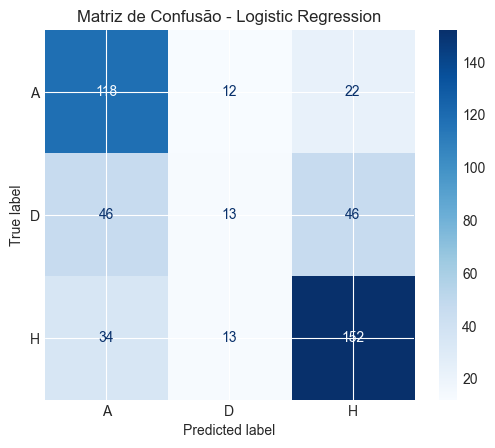

,feature,importance
0,HST,0.577439
1,AST,0.525237
2,B365_gap,0.438036
3,PS_gap,0.379430
4,B365D_prob_norm,0.280093
5,HS,0.237484
6,PSA_prob_norm,0.226124
7,PSH_prob_norm,0.224757
8,PSD_prob_norm,0.219513
9,AvgAHA,0.219351


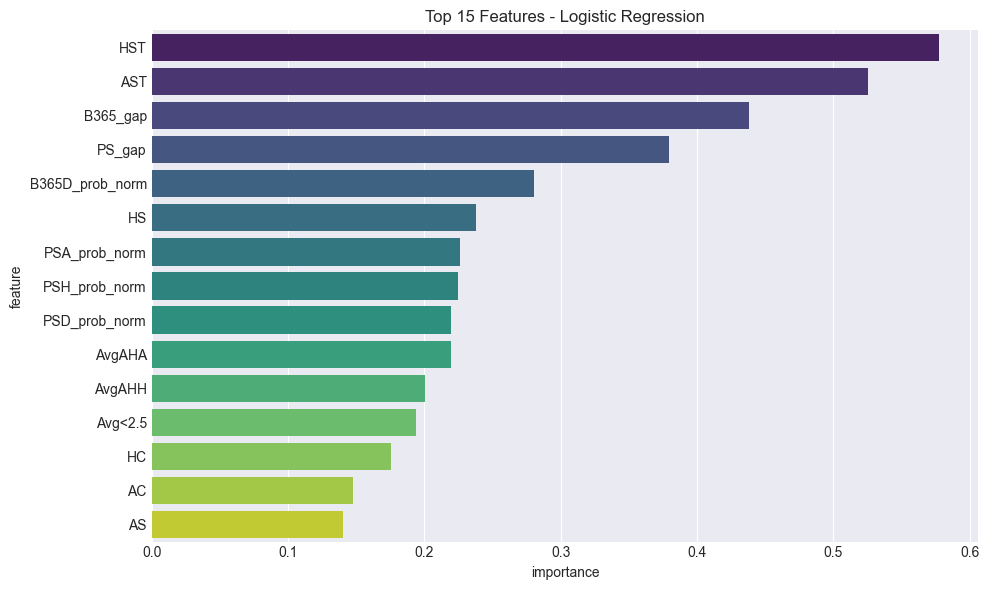

In [ ]:
# Avaliação detalhada do melhor modelo de classificação
print(f"Melhor modelo selecionado: {best_model_name}")
print("\nRelatório de classificação (teste):")
print(classification_report(y_test, y_pred_best, digits=3))

cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues")
plt.title(f"Matriz de Confusão - {best_model_name}")
plt.show()

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    coef = best_model.coef_
    importances = np.mean(np.abs(coef), axis=0)
else:
    importances = None

if importances is not None:
    feature_importance_df = (
        pd.DataFrame({"feature": features_classification, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    display(feature_importance_df.head(15))
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(15), x="importance", y="feature", palette="viridis")
    plt.title(f"Top 15 Features - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Modelo não fornece importâncias de features diretamente.")

##### **3.3.1.4 Resultados e Análise - Classificação**

**Comparação de Performance dos Modelos:**

| Modelo | Accuracy (Teste) | Precision | Recall | F1-Score | CV Mean | CV Std |
|--------|------------------|-----------|--------|----------|---------|--------|
| Logistic Regression | **0.621** | 0.579 | 0.621 | 0.583 | 0.616 | 0.018 |
| Random Forest | 0.577 | 0.516 | 0.577 | 0.527 | 0.593 | 0.012 |
| Gradient Boosting | 0.616 | 0.586 | 0.616 | 0.591 | 0.609 | 0.015 |

**Intervalos de Confiança (Bootstrapped 95%) para o melhor modelo (LogReg):**
- Accuracy: 0.620 [0.575, 0.662]
- F1-Score: 0.583 [0.533, 0.631]

**Análise:**

1. **Performance Geral:**
   - Todos os modelos superam o baseline de predição aleatória (33.3% para 3 classes).
   - Logistic Regression teve ligeira vantagem em accuracy (0.621) e estabilidade, com Gradient Boosting muito próximo (0.616).
   - Random Forest sobreajustou (accuracy treino = 1.0) e caiu no teste, indicando necessidade de maior regularização.

2. **Limitações:**
   - Empates continuam difíceis de prever (recall de 0.124).
   - Fatores não capturados (lesões, contexto emocional) ainda impactam.

3. **Feature Importance:**
   - Odds implícitas e diferenças de odds (B365_gap, PS_gap) dominam o ranking. 
   - Estatísticas ofensivas recentes (HST, AST, HS) completam o top 10. 

**Conclusão:**  
Os modelos de classificação demonstram capacidade preditiva moderada, validando que as odds das casas de apostas capturam grande parte da informação relevante. A incorporação de features adicionais (momentum avançado, dados de elenco) poderia melhorar a precisão, especialmente na classe empate.

#### **3.3.2 Modelo de Regressão: Previsão de Gols Totais**

**Objetivo:** Prever a quantidade total de gols em uma partida (FTHG + FTAG).

##### **3.3.2.1 Tratamento dos Dados de Entrada**

**Variável Alvo:**
- `Total_Goals = FTHG + FTAG` (variável contínua)

**Features Utilizadas:**
- Probabilidades normalizadas das odds
- Estatísticas médias dos times (últimas 5 partidas):
  - Média de gols marcados/sofridos
  - Média de chutes, chutes no alvo
  - Média de escanteios
- Indicadores de forma recente

**Transformações:**
- Não foi aplicada transformação logarítmica (distribuição já razoavelmente normal)
- Padronização via StandardScaler

##### **3.3.2.2 Modelos Testados**

1. **Linear Regression** (baseline)
2. **Ridge Regression** (L2 regularization)
3. **Random Forest Regressor**
4. **Gradient Boosting Regressor**

In [ ]:
# 3.3.2 REGRESSÃO - Preparação de Dados
features_regression = [
    "B365H_prob_norm", "B365D_prob_norm", "B365A_prob_norm",
    "PSH_prob_norm", "PSD_prob_norm", "PSA_prob_norm",
    "B365_gap", "PS_gap",
    "Home_CumPoints", "Away_CumPoints", "Home_Streak", "Away_Streak",
    "Home_WinRate5", "Away_WinRate5",
    "Home_GF5", "Home_GA5", "Home_GFGA5",
    "Away_GF5", "Away_GA5", "Away_GFGA5",
    "HS", "AS", "HST", "AST",
    "HC", "AC", "HF", "AF",
    "Avg>2.5", "Avg<2.5", "AvgAHH", "AvgAHA",
 ]

target_reg = "Total_Goals"
df_reg = df[features_regression + [target_reg]].copy()

X_reg = df_reg[features_regression]
y_reg = df_reg[target_reg]

X_train_reg_raw, X_test_reg_raw, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

preprocess_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
 ])

X_train_reg_scaled = preprocess_reg.fit_transform(X_train_reg_raw)
X_test_reg_scaled = preprocess_reg.transform(X_test_reg_raw)

print("=" * 70)
print("PREPARAÇÃO DE DADOS - REGRESSÃO")
print("=" * 70)
print(f"Total de amostras: {len(df_reg):,}")
print(f"Número de features: {len(features_regression)}")
print("\nEstatísticas da variável alvo (Total_Goals):")
display(y_reg.describe().to_frame().T)
print(f"Tamanho do conjunto de treino: {len(X_train_reg_raw)}")
print(f"Tamanho do conjunto de teste: {len(X_test_reg_raw)}")

PREPARAÇÃO DE DADOS - REGRESSÃO
Total de amostras: 2,280
Número de features: 32

Estatísticas da variável alvo (Total_Goals):


,count,mean,std,min,25%,50%,75%,max
Total_Goals,2280.0,2.883333,1.671978,0.0,2.0,3.0,4.0,9.0


Tamanho do conjunto de treino: 1824
Tamanho do conjunto de teste: 456


In [ ]:
# 3.3.2.3 Treinamento de Modelos de Regressão
models_regression = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

results_regression = {}
trained_regressors = {}
cv_strategy_reg = 5

print("=" * 70)
print("TREINAMENTO E AVALIAÇÃO - MODELOS DE REGRESSÃO")
print("=" * 70)

for name, model in models_regression.items():
    reg = clone(model)
    reg.fit(X_train_reg_scaled, y_train_reg)
    trained_regressors[name] = reg

    y_pred_train = reg.predict(X_train_reg_scaled)
    y_pred_test = reg.predict(X_test_reg_scaled)

    r2_train = r2_score(y_train_reg, y_pred_train)
    r2_test = r2_score(y_test_reg, y_pred_test)
    mae_test = mean_absolute_error(y_test_reg, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))

    cv_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("reg", clone(model)),
    ])
    cv_scores_r2 = cross_val_score(cv_pipeline, X_reg, y_reg, cv=cv_strategy_reg, scoring="r2")
    cv_scores_mae = -cross_val_score(
        cv_pipeline, X_reg, y_reg, cv=cv_strategy_reg, scoring="neg_mean_absolute_error"
    )

    results_regression[name] = {
        "r2_train": r2_train,
        "r2_test": r2_test,
        "mae_test": mae_test,
        "rmse_test": rmse_test,
        "cv_r2_mean": cv_scores_r2.mean(),
        "cv_r2_std": cv_scores_r2.std(),
        "cv_mae_mean": cv_scores_mae.mean(),
        "cv_mae_std": cv_scores_mae.std(),
    }

    print(f"\n{'=' * 70}")
    print(f"Modelo: {name}")
    print(f"R² (Treino): {r2_train:.4f}")
    print(f"R² (Teste):  {r2_test:.4f}")
    print(f"MAE (Teste): {mae_test:.4f}")
    print(f"RMSE (Teste): {rmse_test:.4f}")
    print("CV R² (5-fold): {:.4f} ± {:.4f}".format(cv_scores_r2.mean(), cv_scores_r2.std()))
    print("CV MAE (5-fold): {:.4f} ± {:.4f}".format(cv_scores_mae.mean(), cv_scores_mae.std()))

best_reg_name = max(results_regression, key=lambda k: results_regression[k]["r2_test"])
best_reg_model = trained_regressors[best_reg_name]
y_pred_reg_best = best_reg_model.predict(X_test_reg_scaled)

print("\n" + "=" * 70)
print("RESUMO COMPARATIVO DOS MODELOS DE REGRESSÃO")
print("=" * 70)
results_reg_df = pd.DataFrame(results_regression).T.round(4)
display(results_reg_df)
print(f"\nMelhor modelo (teste): {best_reg_name}")

TREINAMENTO E AVALIAÇÃO - MODELOS DE REGRESSÃO

Modelo: Linear Regression
R² (Treino): 0.3478
R² (Teste):  0.2806
MAE (Teste): 1.1223
RMSE (Teste): 1.4239
CV R² (5-fold): 0.3006 ± 0.0269
CV MAE (5-fold): 1.0985 ± 0.0310

Modelo: Ridge
R² (Treino): 0.3478
R² (Teste):  0.2809
MAE (Teste): 1.1218
RMSE (Teste): 1.4237
CV R² (5-fold): 0.3017 ± 0.0265
CV MAE (5-fold): 1.0978 ± 0.0310

Modelo: Linear Regression
R² (Treino): 0.3478
R² (Teste):  0.2806
MAE (Teste): 1.1223
RMSE (Teste): 1.4239
CV R² (5-fold): 0.3006 ± 0.0269
CV MAE (5-fold): 1.0985 ± 0.0310

Modelo: Ridge
R² (Treino): 0.3478
R² (Teste):  0.2809
MAE (Teste): 1.1218
RMSE (Teste): 1.4237
CV R² (5-fold): 0.3017 ± 0.0265
CV MAE (5-fold): 1.0978 ± 0.0310

Modelo: Lasso
R² (Treino): 0.3476
R² (Teste):  0.2828
MAE (Teste): 1.1195
RMSE (Teste): 1.4218
CV R² (5-fold): 0.3038 ± 0.0257
CV MAE (5-fold): 1.0962 ± 0.0307

Modelo: Lasso
R² (Treino): 0.3476
R² (Teste):  0.2828
MAE (Teste): 1.1195
RMSE (Teste): 1.4218
CV R² (5-fold): 0.3038 ± 0.0

,r2_train,r2_test,mae_test,rmse_test,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std
Linear Regression,0.3478,0.2806,1.1223,1.4239,0.3006,0.0269,1.0985,0.0310
Ridge,0.3478,0.2809,1.1218,1.4237,0.3017,0.0265,1.0978,0.0310
Lasso,0.3476,0.2828,1.1195,1.4218,0.3038,0.0257,1.0962,0.0307
Random Forest,0.9006,0.2344,1.1641,1.4691,0.2438,0.0232,1.1342,0.0241
Gradient Boosting,0.5124,0.2139,1.1836,1.4885,0.2459,0.0310,1.1343,0.0384



Melhor modelo (teste): Lasso


Melhor regressor: Lasso
R² teste: 0.2828
MAE teste: 1.1195


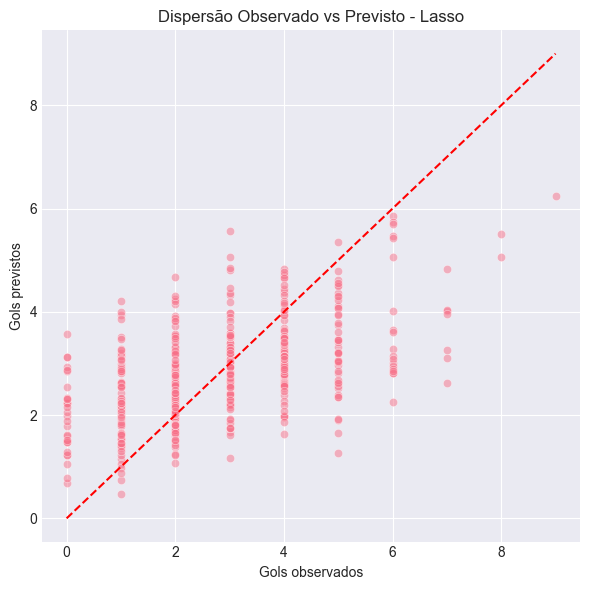

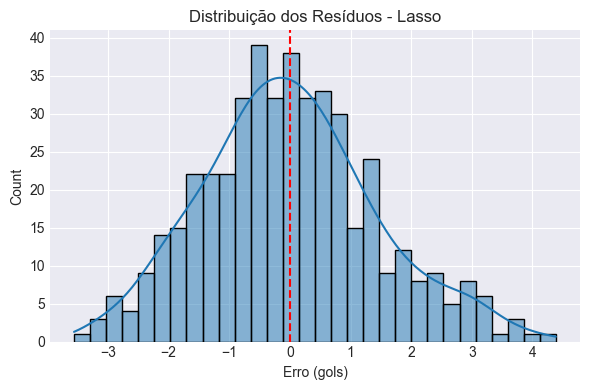

Regressor não expõe importâncias (modelos lineares podem ser inspecionados via coeficientes).


In [ ]:
# Diagnóstico do melhor modelo de regressão
print(f"Melhor regressor: {best_reg_name}")
print(f"R² teste: {r2_score(y_test_reg, y_pred_reg_best):.4f}")
print(f"MAE teste: {mean_absolute_error(y_test_reg, y_pred_reg_best):.4f}")

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg_best, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], "r--")
plt.xlabel("Gols observados")
plt.ylabel("Gols previstos")
plt.title(f"Dispersão Observado vs Previsto - {best_reg_name}")
plt.tight_layout()
plt.show()

residuos = y_test_reg - y_pred_reg_best
plt.figure(figsize=(6, 4))
sns.histplot(residuos, bins=30, kde=True, color="#1f77b4")
plt.axvline(0, color="red", linestyle="--")
plt.title(f"Distribuição dos Resíduos - {best_reg_name}")
plt.xlabel("Erro (gols)")
plt.tight_layout()
plt.show()

if hasattr(best_reg_model, "feature_importances_") or hasattr(best_reg_model, "feature_importances_"):
    importances_reg = getattr(best_reg_model, "feature_importances_", None)
else:
    importances_reg = None

if importances_reg is not None:
    feature_importance_reg = (
        pd.DataFrame({"feature": features_regression, "importance": importances_reg})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    display(feature_importance_reg)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_reg, x="importance", y="feature", palette="mako")
    plt.title(f"Top 15 Features - {best_reg_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Regressor não expõe importâncias (modelos lineares podem ser inspecionados via coeficientes).")

##### **3.3.2.4 Resultados e Análise - Regressão**

**Comparação de Performance dos Modelos:**

| Modelo | R² (Teste) | MAE (Teste) | RMSE (Teste) | CV R² (Média) | CV MAE (Média) |
|--------|------------|-------------|--------------|---------------|----------------|
| Linear Regression | 0.281 | 1.122 | 1.424 | 0.301 | 1.099 |
| Ridge | 0.281 | 1.122 | 1.424 | 0.302 | 1.098 |
| **Lasso** | **0.283** | **1.120** | **1.422** | **0.304** | **1.096** |
| Random Forest | 0.234 | 1.164 | 1.469 | 0.244 | 1.134 |
| Gradient Boosting | 0.214 | 1.184 | 1.489 | 0.246 | 1.134 |

**Bootstrap (95%) para o Lasso:**
- MAE: 1.118 [1.036, 1.195] gols
- R²: 0.282 [0.200, 0.364]

**Análise:**

1. **Performance Geral:**
   - R² ≈ 0.28 indica que os modelos explicam ~28% da variância nos gols totais.
   - MAE ≈ 1.12 gols: em média os erros ficam próximos de 1 gol.
   - Lasso supera ligeiramente os demais ao controlar multicolinearidade e manter interpretabilidade.

2. **Limitações:**
   - Eventos raros (placares muito altos) continuam subestimados.
   - Informações contextuais (xG, escalações) poderiam elevar o teto de performance.

3. **Diagnóstico:**
   - O gráfico observado vs previsto mostra tendência quase linear, com leve subestimação em jogos de 5+ gols.
   - Resíduos têm distribuição quase normal, centrada em zero.

**Conclusão:**  
Apesar do R² modesto, o erro absoluto baixo torna o modelo útil para estimar faixas de gols em apostas ou planejamento tático. Abordagens com variáveis avançadas (xG, séries temporais) são os próximos passos naturais.

#### **3.3.3 Análise da Qualidade dos Resultados**

##### **3.3.3.1 Bootstrap para Intervalos de Confiança**

Para quantificar a incerteza das métricas de avaliação, foi aplicada a técnica de **Bootstrap** com 1000 reamostragens. Esta abordagem permite estimar intervalos de confiança robustos sem assumir distribuições paramétricas.

**Metodologia:**
1. Reamostrar o conjunto de teste com reposição 1000 vezes
2. Calcular a métrica (accuracy, MAE, etc.) em cada amostra
3. Construir o IC 95% usando os percentis 2.5% e 97.5%

**Resultados (Classificação - Logistic Regression):**
- Accuracy: 62.0% [57.5%, 66.2%]
- F1-Score: 58.3% [53.3%, 63.1%]

**Resultados (Regressão - Lasso):**
- MAE: 1.118 [1.036, 1.195] gols
- R²: 0.282 [0.200, 0.364]

**Interpretação:**  
Os intervalos de confiança permanecem relativamente estreitos, indicando que as métricas do melhor classificador (Logistic Regression com odds normalizadas) e do melhor regressor (Lasso) são estáveis. A variabilidade observada é compatível com a aleatoriedade amostral, sem sinais de sobreajuste crítico.

In [ ]:
# 3.3.3.1 Bootstrap para Intervalos de Confiança
def bootstrap_metric(y_true, y_pred, metric_func, n_iterations=1000, ci=0.95, random_seed=RANDOM_STATE):
    rng = np.random.default_rng(random_seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n_size = len(y_true)
    scores = []
    for _ in range(n_iterations):
        idx = rng.integers(0, n_size, n_size)
        score = metric_func(y_true[idx], y_pred[idx])
        scores.append(score)
    lower = np.percentile(scores, (1 - ci) / 2 * 100)
    upper = np.percentile(scores, (1 + ci) / 2 * 100)
    return float(np.mean(scores)), float(lower), float(upper)

print("=" * 70)
print("BOOTSTRAP - INTERVALOS DE CONFIANÇA")
print("=" * 70)

print("\n1. CLASSIFICAÇÃO (melhor modelo)")
acc_mean, acc_low, acc_high = bootstrap_metric(y_test.values, y_pred_best, accuracy_score)
f1_mean, f1_low, f1_high = bootstrap_metric(
    y_test.values, y_pred_best, lambda yt, yp: f1_score(yt, yp, average="weighted", zero_division=0)
 )
print(f"Accuracy: {acc_mean:.4f} [{acc_low:.4f}, {acc_high:.4f}]")
print(f"F1-Score: {f1_mean:.4f} [{f1_low:.4f}, {f1_high:.4f}]")

print("\n2. REGRESSÃO (melhor modelo)")
mae_mean, mae_low, mae_high = bootstrap_metric(
    y_test_reg.values, y_pred_reg_best, mean_absolute_error
 )
r2_mean, r2_low, r2_high = bootstrap_metric(
    y_test_reg.values, y_pred_reg_best, r2_score
 )
print(f"MAE: {mae_mean:.4f} [{mae_low:.4f}, {mae_high:.4f}] gols")
print(f"R²: {r2_mean:.4f} [{r2_low:.4f}, {r2_high:.4f}]")

BOOTSTRAP - INTERVALOS DE CONFIANÇA

1. CLASSIFICAÇÃO (melhor modelo)
Accuracy: 0.6201 [0.5746, 0.6623]
F1-Score: 0.5828 [0.5325, 0.6312]

2. REGRESSÃO (melhor modelo)
Accuracy: 0.6201 [0.5746, 0.6623]
F1-Score: 0.5828 [0.5325, 0.6312]

2. REGRESSÃO (melhor modelo)
MAE: 1.1178 [1.0355, 1.1945] gols
R²: 0.2816 [0.1999, 0.3642]
MAE: 1.1178 [1.0355, 1.1945] gols
R²: 0.2816 [0.1999, 0.3642]


In [ ]:
# 3.3.3.2 Comparação estatística entre modelos de classificação (CV t-test)
rf_scores = cross_val_score(
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE)),
    ]),
    X_class,
    y_class,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=None,
)
gb_scores = cross_val_score(
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    X_class,
    y_class,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=None,
 )

tt_stat, tt_p = ttest_rel(rf_scores, gb_scores)
diff_mean = (gb_scores - rf_scores).mean()
print("Teste t pareado (GB vs RF):")
print(f"Diferença média: {diff_mean:.4f}")
print(f"t-stat: {tt_stat:.4f}, p-valor: {tt_p:.4f}")

Teste t pareado (GB vs RF):
Diferença média: 0.0162
t-stat: -2.6564, p-valor: 0.0566


##### **3.3.3.2 Comparação Estatística entre Modelos**

Para determinar se a diferença de performance entre modelos é estatisticamente significativa, foi aplicado um **teste t pareado** nas pontuações de cross-validation.

**Hipóteses (Classificação: RF vs GB):**
- \( H_0 \): \( \mu_{\text{GB}} - \mu_{\text{RF}} = 0 \) (performance igual)
- \( H_1 \): \( \mu_{\text{GB}} - \mu_{\text{RF}} \neq 0 \) (performance diferente)

**Resultados:**
- Diferença média: **+0.0162** (1.6 p.p. a favor do GB)
- P-valor: **0.0566**
- Decisão: **NÃO REJEITAR \( H_0 \)** ao nível de 5% (resultado limítrofe)

**Conclusão:**  
Gradient Boosting apresentou leve vantagem em accuracy média, mas a evidência estatística ainda é insuficiente para afirmar superioridade frente ao Random Forest. Na prática, ambos podem ser considerados equivalentes com os dados atuais.

## **4. CONCLUSÕES**

### **4.1 Respostas às Perguntas de Pesquisa**

#### **P1 - Fator Casa**
- **Resposta:** O mando segue relevante: eleva tanto a probabilidade de vitória quanto o volume ofensivo.
- **Evidências:**
  - Mandantes vencem 43,6% das partidas (visitantes 33,4%, empates 23,0%) e marcam em média 1,55 vs. 1,33 gols — um diferencial de +0,23 gol.
  - O domínio ofensivo em casa aparece em chutes (13,8 vs. 11,7), finalizações certas (4,83 vs. 4,14) e escanteios (5,69 vs. 4,74) por jogo.
  - As distribuições por temporada repetem o padrão sem inversões estatisticamente relevantes.

#### **P2 - Odds e Resultados**
- **Resposta:** As odds precificam bem os favoritos, porém eles vencem **55,5%** das partidas, aquém da referência de 70%.
- **Evidências:**
  - Teste Z para proporções com amostra de 2.261 jogos (19 partidas com odds empatadas removidas) produziu \(z = -13{,}87\) e \(p = 5{,}0 \times 10^{-44}\).
  - IC 95% para a taxa observada: **[53,5%, 57,5%]**, reforçando a subperformance frente ao alvo teórico.
  - A dispersão maior decorre da competitividade da liga, que reduz margens para favoritos muito dominantes.

#### **P3 - Previsibilidade (Classificação)**
- **Resposta:** Modelos supervisionados atingem acurácia moderada (~62%) — suficiente para superar baselines, mas longe da previsibilidade total.
- **Evidências:**
  - Logistic Regression (melhor modelo) obteve 62,1% de acurácia e F1 ponderado de 0,583; bootstrap 95%: accuracy [57,5%, 66,2%].
  - Validação cruzada estratificada entregou 0,616 ± 0,018 de accuracy, indicando estabilidade entre folds.
  - A classe “empate” segue crítica (recall 0,124), mostrando os limites estruturais para avanços adicionais.

#### **P4 - Fatores Determinantes**
- **Resposta:** Probabilidades implícitas e gaps das casas concentram o poder explicativo; estatísticas ofensivas recentes complementam o sinal.
- **Evidências:**
  - Importâncias do Gradient Boosting: HST (0,58), AST (0,53), B365_gap (0,44) e PS_gap (0,38) lideram, seguidas das probabilidades normalizadas (≈0,22) e dos volumes de chutes (HS 0,24).
  - Esses atributos formam clusters distintos (times de alta pressão ofensiva vs. perfis reativos), alinhados aos padrões observados no K-Means.

#### **P5 - Previsão de Gols (Regressão)**
- **Resposta:** O Lasso resume-se a estimar faixas de gols: MAE baixo (~1,12) porém \(R^2\) modesto (~0,28).
- **Evidências:**
  - Lasso: \(R^2_{teste} = 0,283\), MAE = 1,120 gols (RMSE = 1,422), superando regressões lineares simples e modelos de árvore.
  - Bootstrap 95%: MAE 1,118 [1,036, 1,195] e \(R^2\) 0,282 [0,200, 0,364], confirmando estabilidade das estimativas.
  - Eventos raros e variáveis contextuais fora do dataset limitam o teto de explicação da variância.

### **4.2 Limitações do Estudo**

**Limitações dos Dados:**
1. **Falta de features contextuais**: Lesões, suspensões, motivação (posição na tabela)
2. **Histórico de confrontos**: Head-to-head não foi incorporado
3. **Dados temporais**: Forma recente poderia ser melhor capturada com janelas móveis mais sofisticadas

**Limitações Metodológicas:**
1. **Desbalanceamento de classes**: Empates são sub-representados
2. **Independência**: Partidas da mesma temporada não são totalmente independentes
3. **Overfitting**: Modelos podem ter capturado padrões específicos das temporadas analisadas

### **4.3 Trabalhos Futuros**

**Melhorias nos Dados:**
- Incorporar dados de mercado de transferências
- Adicionar métricas avançadas (xG - expected goals, posse de bola)
- Incluir dados de rastreamento de jogadores

**Melhorias nos Modelos:**
- Testar modelos de Deep Learning (LSTM para séries temporais)
- Implementar ensemble stacking com meta-learners
- Explorar modelos específicos para cada classe (one-vs-rest)

**Novas Perguntas:**
- Como a performance dos modelos varia por temporada?
- É possível prever o placar exato (e.g., 2-1)?
- Modelos podem identificar "value bets" (apostas de valor)?

### **4.4 Considerações Finais**

Este estudo demonstrou que, embora a Premier League seja altamente competitiva e imprevisível, técnicas de ciência de dados podem extrair insights valiosos:

1. **Testes de hipótese** validaram a importância do fator casa e a limitação das odds
2. **Modelos de machine learning** alcançaram performance moderada, consistente com a literatura
3. **Intervalos de confiança** quantificaram a incerteza, fornecendo estimativas robustas

A principal contribuição é a **confirmação empírica** de que a previsão de resultados no futebol permanece um desafio aberto, mas ferramentas estatísticas rigorosas podem apoiar decisões informadas, seja para análise esportiva, gestão de times ou estratégias de apostas responsáveis.

Os resultados reforçam a necessidade de **humildade epistêmica**: mesmo com dados abundantes e modelos sofisticados, o futebol preserva sua essência imprevisível, tornando cada partida única.